# Notebook 06 — Scraping MINSA/CDC y Calidad de Datos

**Proyecto:** Sistema de Predicción de Demanda Hospitalaria — EsSalud
**Curso:** Big Data DD283 (2026-1) · **Grupo 3** · Junior Ortiz
**Semana 7 del cronograma**

---

## Criterio de éxito (README §8, fila S7)

| Requisito | Meta | Fuente |
|-----------|------|--------|
| Integración MINSA | Datos MINSA integrados | Sección 8 |
| Calidad de datos | **8 validaciones** Great Expectations | Sección 8 |
| Fuente epidemiológica | MINSA boletín / MINSA-CDC | Sección 6 |
| Herramienta | Great Expectations — validar registros HIS | Sección 6 |

## Contenido

1. Verificación de disponibilidad de fuentes MINSA
2. Diagnóstico de las fuentes que fallaron
3. Rastreo de enlaces y rutas alternativas
4. Exploración de las fuentes viables
5. Localización del recurso descargable
6. Descarga del dataset CDC/RENACE
7. Carga y filtrado a la ventana del proyecto
8. Agregación semanal y contraste con la serie sintética
9. Corrección metodológica y separación de efectos
10. Estimación del rezago clima-dengue y contraste con H1
11. Carga de la capa Plata para validación de calidad
12. Great Expectations — 8 validaciones sobre registros HIS
13. Control de veracidad — cuarto campo duplicado
14. Conclusiones

## Antecedente

El README (§6) señala `www.minsa.gob.pe/noticias` como fuente de epidemiología.
Esa URL responde **403 sin redirección**: el MINSA migró a la plataforma unificada
del Estado (`gob.pe/minsa`). Las celdas 1 a 5 documentan la evaluación de cuatro
rutas alternativas y la elección del dataset de vigilancia epidemiológica del
**CDC/RENACE** en el portal de datos abiertos, coherente con lo que el README
define como fuente: "MINSA/CDC".

> **Alcance de la integración:** los datos del CDC se incorporan como fuente
> **externa de validación**, no al pipeline Medallion. Los datos del proyecto son
> sintéticos y su hash está comprometido desde la EP. Esta fuente sirve para
> contrastar el generador contra vigilancia epidemiológica real.

> **Versión de Great Expectations:** se usa 0.18.15, ya instalada. No se actualizó
> a 1.x porque esa versión modifica restricciones de `numpy` y `altair`, y el
> entorno actual es aquel en el que el notebook 05 quedó verificado como
> reproducible.

In [1]:
# ============================================================
#  1. VERIFICACION DE DISPONIBILIDAD DE FUENTES MINSA
# ============================================================
# El README (seccion 6) define MINSA como fuente de epidemiologia y
# apunta a www.minsa.gob.pe/noticias. Antes de construir cualquier
# parser se verifica que fuentes responden y cuales sirven realmente.
#
# Se prueban tres candidatas:
#   1. Portal de datos abiertos - dataset CDC/RENACE de vigilancia de
#      dengue (datos estructurados, serie historica por semana epi.)
#   2. Sala situacional del CDC (dge.gob.pe) - publicacion semanal
#   3. La URL literal del README (seccion de noticias)

import requests
import pandas as pd

HEADERS = {"User-Agent": "Mozilla/5.0 (compatible; proyecto-academico-DD283)"}

FUENTES = {
    "datos_abiertos_dengue":
        "https://datosabiertos.gob.pe/dataset/vigilancia-epidemiol%C3%B3gica-de-dengue",
    "cdc_sala_situacional":
        "https://www.dge.gob.pe/sala-situacional-dengue/",
    "cdc_portal":
        "https://www.dge.gob.pe/portalnuevo/",
    "readme_minsa_noticias":
        "https://www.minsa.gob.pe/noticias/",
}

filas = []
for nombre, url in FUENTES.items():
    try:
        r = requests.get(url, headers=HEADERS, timeout=30)
        filas.append({
            "fuente": nombre,
            "status": r.status_code,
            "tipo": r.headers.get("Content-Type", "")[:40],
            "tamano_kb": round(len(r.content) / 1024, 1),
            "resultado": "OK" if r.status_code == 200 else "REVISAR",
        })
    except Exception as e:
        filas.append({
            "fuente": nombre, "status": None, "tipo": "",
            "tamano_kb": 0, "resultado": f"ERROR: {type(e).__name__}",
        })

disponibilidad = pd.DataFrame(filas)
print("Disponibilidad de fuentes MINSA/CDC\n")
display(disponibilidad)

ok = int((disponibilidad["resultado"] == "OK").sum())
print(f"\nFuentes accesibles: {ok} de {len(FUENTES)}")

Disponibilidad de fuentes MINSA/CDC



,fuente,status,tipo,tamano_kb,resultado
0,datos_abiertos_dengue,NaN,,0.0,ERROR: ConnectionError
1,cdc_sala_situacional,200.0,text/html; charset=UTF-8,0.1,OK
2,cdc_portal,200.0,text/html; charset=UTF-8,261.3,OK
3,readme_minsa_noticias,403.0,text/html; charset=UTF-8,4.4,REVISAR



Fuentes accesibles: 2 de 4


In [2]:
# ============================================================
#  2. DIAGNOSTICO DE LAS FUENTES QUE FALLARON
# ============================================================
# Antes de descartar una fuente hay que saber POR QUE falla:
# no es lo mismo un bloqueo, una redireccion o un sitio caido.

import socket

# --- A. datosabiertos.gob.pe: resolucion DNS y detalle del error ---
print("A) datosabiertos.gob.pe")
try:
    ip = socket.gethostbyname("datosabiertos.gob.pe")
    print(f"   DNS resuelve a: {ip}")
except Exception as e:
    print(f"   DNS NO resuelve -> {type(e).__name__}: {e}")

for intento, url in [("https", "https://datosabiertos.gob.pe/"),
                     ("http",  "http://datosabiertos.gob.pe/")]:
    try:
        r = requests.get(url, headers=HEADERS, timeout=20)
        print(f"   {intento}: status {r.status_code}, {len(r.content)/1024:.1f} KB")
    except Exception as e:
        print(f"   {intento}: {type(e).__name__} -> {str(e)[:120]}")

# --- B. sala situacional: ver que contienen esos 100 bytes ---
print("\nB) dge.gob.pe/sala-situacional-dengue/")
r = requests.get("https://www.dge.gob.pe/sala-situacional-dengue/",
                 headers=HEADERS, timeout=30)
print(f"   Status: {r.status_code} | Bytes: {len(r.content)}")
print(f"   Historial de redirecciones: {[h.status_code for h in r.history]}")
print(f"   URL final: {r.url}")
print("   --- contenido completo ---")
print(r.text[:600])

# --- C. portal CDC: confirmar que trae contenido util ---
print("\nC) dge.gob.pe/portalnuevo/  (la fuente que si respondio)")
r2 = requests.get("https://www.dge.gob.pe/portalnuevo/", headers=HEADERS, timeout=30)
print(f"   Status: {r2.status_code} | Bytes: {len(r2.content):,}")
texto = r2.text.lower()
for palabra in ["dengue", "sala situacional", "boletin", "metaxenicas", ".pdf", ".xlsx", ".csv"]:
    print(f"   contiene '{palabra}': {texto.count(palabra)} veces")

A) datosabiertos.gob.pe
   DNS NO resuelve -> gaierror: [Errno 11001] getaddrinfo failed
   https: ConnectionError -> HTTPSConnectionPool(host='datosabiertos.gob.pe', port=443): Max retries exceeded with url: / (Caused by NameResolutionEr
   http: ConnectionError -> HTTPConnectionPool(host='datosabiertos.gob.pe', port=80): Max retries exceeded with url: / (Caused by NameResolutionErro

B) dge.gob.pe/sala-situacional-dengue/
   Status: 200 | Bytes: 99
   Historial de redirecciones: [302]
   URL final: https://app7.dge.gob.pe/maps/sala_metaxenica/
   --- contenido completo ---
<script>
  window.location.href = "https://app7.dge.gob.pe/maps2/shiny_metaxenicas_web/";
</script>

C) dge.gob.pe/portalnuevo/  (la fuente que si respondio)
   Status: 200 | Bytes: 267,543
   contiene 'dengue': 3 veces
   contiene 'sala situacional': 2 veces
   contiene 'boletin': 4 veces
   contiene 'metaxenicas': 0 veces
   contiene '.pdf': 4 veces
   contiene '.xlsx': 0 veces
   contiene '.csv': 0 veces


In [3]:
# ============================================================
#  3. RASTREO DE ENLACES Y RUTAS ALTERNATIVAS
# ============================================================
# A) La sala situacional resulto ser una app Shiny (R) que renderiza por
#    WebSocket: no es scrapeable con requests + BeautifulSoup.
# B) datosabiertos.gob.pe no resuelve por DNS desde esta red. Se prueban
#    variantes del dominio antes de descartar la fuente.
# C) El portal del CDC si devuelve HTML: se extraen todos sus enlaces.

from bs4 import BeautifulSoup
from urllib.parse import urljoin

# --- A. Variantes de dominio para datos abiertos ---
print("A) Rutas alternativas para datos abiertos\n")
ALTERNATIVAS = [
    "https://www.datosabiertos.gob.pe/",
    "https://datosabiertos.gob.pe/dataset/",
    "https://www.gob.pe/",
    "https://cdn.www.gob.pe/",
    "https://app7.dge.gob.pe/",
]
for url in ALTERNATIVAS:
    try:
        r = requests.get(url, headers=HEADERS, timeout=20)
        print(f"   {url:45s} -> {r.status_code}  ({len(r.content)/1024:.1f} KB)")
    except Exception as e:
        print(f"   {url:45s} -> {type(e).__name__}")

# --- B. Todos los enlaces del portal CDC ---
print("\nB) Enlaces encontrados en dge.gob.pe/portalnuevo/\n")
r = requests.get("https://www.dge.gob.pe/portalnuevo/", headers=HEADERS, timeout=30)
soup = BeautifulSoup(r.text, "html.parser")

enlaces = []
for a in soup.find_all("a", href=True):
    href = urljoin("https://www.dge.gob.pe/portalnuevo/", a["href"])
    texto = " ".join(a.get_text(strip=True).split())[:60]
    enlaces.append({"texto": texto, "url": href})

df_enl = pd.DataFrame(enlaces).drop_duplicates(subset="url")
print(f"Total de enlaces unicos: {len(df_enl)}\n")

# Filtrar los relevantes
patron = r"dengue|boletin|sala|epidemiolog|vigilancia|\.pdf|\.csv|\.xlsx"
relevantes = df_enl[
    df_enl["url"].str.contains(patron, case=False, na=False) |
    df_enl["texto"].str.contains(patron, case=False, na=False)
].reset_index(drop=True)

print(f"Enlaces potencialmente utiles: {len(relevantes)}\n")
pd.set_option("display.max_colwidth", 95)
display(relevantes)

A) Rutas alternativas para datos abiertos

   https://www.datosabiertos.gob.pe/             -> 200  (79.6 KB)
   https://datosabiertos.gob.pe/dataset/         -> ConnectionError
   https://www.gob.pe/                           -> 200  (228.3 KB)
   https://cdn.www.gob.pe/                       -> 200  (0.0 KB)
   https://app7.dge.gob.pe/                      -> 200  (7.0 KB)

B) Enlaces encontrados en dge.gob.pe/portalnuevo/

Total de enlaces unicos: 83

Enlaces potencialmente utiles: 18



,texto,url
0,INTRANETINTRANET,https://www.dge.gob.pe/portalnuevo/area-privada/aplicativos-para-la-vigilancia/
1,Vigilancia en Salud Pública,https://www.dge.gob.pe/portalnuevo/vigilancia-epidemiologica/#tab1-vigilancia
2,Unidades de Vigilancia en Salud Pública,https://www.dge.gob.pe/portalnuevo/vigilancia-epidemiologica/#tab2-Unidades-Tecnicas
3,Salas de situación de salud,https://www.dge.gob.pe/portalnuevo/vigilancia-epidemiologica/#tab3-salas-vsp
4,Investigación y Evaluación,https://www.dge.gob.pe/portalnuevo/inteligencia-sanitaria/investigacion-monitoreo-y-evaluac...
5,Capacitación. Programa de Entrenamiento en Epidemiología de,https://www.dge.gob.pe/portalnuevo/inteligencia-sanitaria/capacitacion-programa-de-enfermed...
6,Boletines epidemiológicos,https://www.dge.gob.pe/portalnuevo/informacion-publica/boletines-epidemiologicos/
7,Avisos y alertas epidemiológicas,https://www.dge.gob.pe/portalnuevo/informacion-publica/avisos-y-alertas-epidemiologicas/
8,Vigilancia de eventos sanitarios en medios de comunicación,https://www.dge.gob.pe/portalnuevo/respuesta-a-brotes-y-otros-evisap/inteligencia-epidemica...
9,Indicadores de anemia,https://sala-anemia.dge.gob.pe/


In [4]:
# ============================================================
#  4. EXPLORACION DE LAS FUENTES VIABLES
# ============================================================
# HALLAZGOS PREVIOS:
#  - El dominio sin 'www' no resuelve por DNS; www.datosabiertos.gob.pe si.
#  - La sala situacional es una app Shiny (R): no scrapeable con requests.
#  - El MINSA migro a la plataforma unificada del Estado (gob.pe/minsa),
#    por lo que la URL del README (www.minsa.gob.pe/noticias) es heredada
#    y responde 403.
#
# Se exploran las tres rutas viables.

BASE_DA  = "https://www.datosabiertos.gob.pe"
BASE_GOB = "https://www.gob.pe"

def explorar(url, params=None, filtro=None, etiqueta="", n=12):
    """Descarga una pagina y extrae sus enlaces, opcionalmente filtrados."""
    try:
        r = requests.get(url, params=params, headers=HEADERS, timeout=30)
        print(f"   {etiqueta}: status {r.status_code} "
              f"({len(r.content)/1024:.1f} KB) | URL final: {r.url[:80]}")
        if r.status_code != 200:
            return pd.DataFrame()
        s = BeautifulSoup(r.text, "html.parser")
        filas = [{"texto": " ".join(a.get_text(strip=True).split())[:65],
                  "url": urljoin(r.url, a["href"])}
                 for a in s.find_all("a", href=True)]
        df = pd.DataFrame(filas).drop_duplicates(subset="url")
        if filtro:
            df = df[df["url"].str.contains(filtro, case=False, na=False) |
                    df["texto"].str.contains(filtro, case=False, na=False)]
        return df.reset_index(drop=True)
    except Exception as e:
        print(f"   {etiqueta}: ERROR {type(e).__name__} -> {str(e)[:100]}")
        return pd.DataFrame()

pd.set_option("display.max_colwidth", 95)

# --- A. Portal de datos abiertos: buscar datasets de dengue ---
print("A) Portal de datos abiertos\n")
df_ds = explorar(f"{BASE_DA}/search/type/dataset", params={"query": "dengue"},
                 filtro=r"/dataset/", etiqueta="buscador")
print(f"   Datasets encontrados: {len(df_ds)}\n")
display(df_ds.head(12))

# --- B. Boletines epidemiologicos del CDC ---
print("\nB) Boletines epidemiologicos del CDC\n")
df_bol = explorar("https://www.dge.gob.pe/portalnuevo/informacion-publica/"
                  "boletines-epidemiologicos/",
                  filtro=r"\.pdf|boletin|\d{4}", etiqueta="boletines")
print(f"   Enlaces relevantes: {len(df_bol)}\n")
display(df_bol.head(12))

# --- C. MINSA en la plataforma del Estado (gob.pe) ---
print("\nC) MINSA en gob.pe\n")
# C1. Verificar que hace el dominio heredado del README
try:
    rv = requests.get("https://www.minsa.gob.pe/noticias/", headers=HEADERS,
                      timeout=20, allow_redirects=True)
    print(f"   URL del README -> status {rv.status_code} | "
          f"redirecciones: {[h.status_code for h in rv.history]} | "
          f"destino: {rv.url[:80]}")
except Exception as e:
    print(f"   URL del README -> {type(e).__name__}")

# C2. Rutas de la plataforma unificada
for ruta, etq in [("/minsa", "portada MINSA"),
                  ("/institucion/minsa/noticias", "noticias"),
                  ("/institucion/minsa/informes-publicaciones", "publicaciones")]:
    df_g = explorar(f"{BASE_GOB}{ruta}", filtro=r"dengue|epidemiolog|boletin|\.pdf",
                    etiqueta=etq)
    if len(df_g):
        print(f"      -> {len(df_g)} enlaces relevantes")
        display(df_g.head(6))
    print()

A) Portal de datos abiertos

   buscador: status 200 (64.2 KB) | URL final: https://www.datosabiertos.gob.pe/search/type/dataset?query=dengue
   Datasets encontrados: 10



,texto,url
0,Casos de Dengue en la Región Piura [Gobierno Regional Piura],https://www.datosabiertos.gob.pe/dataset/casos-de-dengue-en-la-regi%C3%B3n-piura-gobierno-r...
1,Encuesta Nacional de Programas Presupuestales (ENAPRES) 2025 - [I,https://www.datosabiertos.gob.pe/dataset/encuesta-nacional-de-programas-presupuestales-enap...
2,Vigilancia Epidemiológica de las zoonosis,https://www.datosabiertos.gob.pe/dataset/vigilancia-epidemiol%C3%B3gica-de-las-zoonosis
3,vigilancia epidemiológica de leishmaniosis,https://www.datosabiertos.gob.pe/dataset/vigilancia-epidemiol%C3%B3gica-de-leishmaniosis
4,Vigilancia epidemiológica de Malaria,https://www.datosabiertos.gob.pe/dataset/vigilancia-epidemiol%C3%B3gica-de-malaria
5,Vigilancia Epidemiológica de dengue,https://www.datosabiertos.gob.pe/dataset/vigilancia-epidemiol%C3%B3gica-de-dengue
6,ENFERMEDADES METAXENICAS,https://www.datosabiertos.gob.pe/dataset/enfermedades-metaxenicas
7,Encuesta Nacional de Programas Presupuestales (ENAPRES) 2024 - [I,https://www.datosabiertos.gob.pe/dataset/encuesta-nacional-de-programas-presupuestales-enap...
8,Encuesta Nacional de Programas Presupuestales (ENAPRES) 2023 - [I,https://www.datosabiertos.gob.pe/dataset/encuesta-nacional-de-programas-presupuestales-enap...
9,Encuesta Nacional de Programas Presupuestales (ENAPRES) 2022 - [I,https://www.datosabiertos.gob.pe/dataset/encuesta-nacional-de-programas-presupuestales-enap...



B) Boletines epidemiologicos del CDC

   boletines: status 200 (221.2 KB) | URL final: https://www.dge.gob.pe/portalnuevo/informacion-publica/boletines-epidemiologicos
   Enlaces relevantes: 3



,texto,url
0,Skip to content,https://www.dge.gob.pe/portalnuevo/informacion-publica/boletines-epidemiologicos/#content
1,NOSOTROS,https://www.dge.gob.pe/portalnuevo/informacion-publica/boletines-epidemiologicos/
2,Calendario epidemiológico 2026,https://www.dge.gob.pe/portalnuevo/wp-content/uploads/2026/01/CALENDARIO-EPIDEMIOLOGICO-PAR...



C) MINSA en gob.pe

   URL del README -> status 403 | redirecciones: [] | destino: https://www.minsa.gob.pe/noticias/
   portada MINSA: status 200 (276.8 KB) | URL final: https://www.gob.pe/minsa
      -> 6 enlaces relevantes


,texto,url
0,Organigrama,https://www.gob.pe/rails/active_storage/blobs/redirect/eyJfcmFpbHMiOnsiZGF0YSI6MTc0MDAsInB1...
1,Minsa brinda recomendaciones a viajeros para evitar enfermar por,https://www.gob.pe/institucion/minsa/noticias/1422781-minsa-brinda-recomendaciones-a-viajer...
2,Minsa intensifica acciones contra el dengue y despliega brigadas,https://www.gob.pe/institucion/minsa/noticias/1422571-minsa-intensifica-acciones-contra-el-...
3,"Centro Nacional de Epidemiología, Prevención y Control de Enferme",https://www.dge.gob.pe/portalnuevo/
4,Alertas epidemiológicas,https://www.dge.gob.pe/portalnuevo/informacion-publica/alertas-epidemiologicas/
5,Aplicativo para prevención del dengue PromoApp Administrador,https://appdengueadmin.dge.gob.pe/



   noticias: status 200 (208.2 KB) | URL final: https://www.gob.pe/institucion/minsa/noticias
      -> 3 enlaces relevantes


,texto,url
0,Organigrama,https://www.gob.pe/rails/active_storage/blobs/redirect/eyJfcmFpbHMiOnsiZGF0YSI6MTc0MDAsInB1...
1,Minsa brinda recomendaciones a viajeros para evitar enfermar por,https://www.gob.pe/institucion/minsa/noticias/1422781-minsa-brinda-recomendaciones-a-viajer...
2,Minsa intensifica acciones contra el dengue y despliega brigadas,https://www.gob.pe/institucion/minsa/noticias/1422571-minsa-intensifica-acciones-contra-el-...



   publicaciones: status 200 (207.1 KB) | URL final: https://www.gob.pe/institucion/minsa/informes-publicaciones
      -> 27 enlaces relevantes


,texto,url
0,Organigrama,https://www.gob.pe/rails/active_storage/blobs/redirect/eyJfcmFpbHMiOnsiZGF0YSI6MTc0MDAsInB1...
1,Descargar,https://cdn.www.gob.pe/uploads/document/file/10322497/8389148-instructivo-de-inscripcion-a-...
2,Descargar,https://cdn.www.gob.pe/uploads/document/file/10322495/8389146-cronograma-evalpas-2026-ii-wo...
3,Descargar,https://cdn.www.gob.pe/uploads/document/file/10322493/8389144-convocatoria-al-proceso-de-ev...
4,Descargar,https://cdn.www.gob.pe/uploads/document/file/9598727/7857089-norma-cred-12-03-26.pdf
5,Descargar,https://cdn.www.gob.pe/uploads/document/file/10357649/8414349-acta-39-sesion-cns-18-12-2025...


In [5]:
# ============================================================
#  5. LOCALIZACION DEL RECURSO DESCARGABLE
# ============================================================
# DECISION: se adopta el dataset "Vigilancia Epidemiologica de dengue"
# del portal de datos abiertos (CDC/RENACE). Justificacion:
#   - Es la unica fuente con datos ESTRUCTURADOS por semana epidemiologica.
#   - Coincide con lo que el README (seccion 6) define como fuente de
#     epidemiologia: "MINSA/CDC".
#   - La portada del MINSA en gob.pe enlaza al CDC como autoridad tecnica.
#
# Rutas descartadas y por que:
#   - www.minsa.gob.pe/noticias (URL del README): 403 SIN redirecciones.
#   - gob.pe/institucion/minsa/noticias: notas de prensa, texto libre.
#   - Sala situacional del CDC: app Shiny (R), render por WebSocket.
#   - Boletines del CDC: enlaces cargados dinamicamente.
#
# El portal usa CKAN, que expone una API REST. Se prueban ambas vias:
# la API (preferible, devuelve JSON) y el scraping del HTML (respaldo).

import json, re

# --- Tomar la URL del dataset desde los resultados, sin escribirla a mano ---
m = df_ds[df_ds["texto"].str.contains("Vigilancia", case=False, na=False) &
          df_ds["texto"].str.contains("dengue", case=False, na=False)]
if m.empty:
    raise ValueError("No se localizo el dataset de vigilancia de dengue.")
URL_DATASET = m.iloc[0]["url"]
slug = URL_DATASET.rstrip("/").split("/dataset/")[-1]
print(f"Dataset : {m.iloc[0]['texto']}")
print(f"URL     : {URL_DATASET}")
print(f"Slug    : {slug}\n")

# --- A. Via API de CKAN ---
print("A) API CKAN (package_show)\n")
recursos = pd.DataFrame()
try:
    ra = requests.get(f"{BASE_DA}/api/3/action/package_show",
                      params={"id": slug}, headers=HEADERS, timeout=30)
    print(f"   Status: {ra.status_code}")
    if ra.status_code == 200:
        j = ra.json()
        res = j.get("result", {}).get("resources", [])
        print(f"   Recursos declarados: {len(res)}\n")
        recursos = pd.DataFrame([{
            "nombre": (r.get("name") or "")[:55],
            "formato": r.get("format"),
            "tamano": r.get("size"),
            "url": r.get("url"),
        } for r in res])
        display(recursos)
except Exception as e:
    print(f"   ERROR: {type(e).__name__} -> {str(e)[:120]}")

# --- B. Respaldo: scraping del HTML del dataset ---
if recursos.empty:
    print("\nB) Respaldo: enlaces de descarga en el HTML\n")
    rb = requests.get(URL_DATASET, headers=HEADERS, timeout=30)
    print(f"   Status: {rb.status_code} ({len(rb.content)/1024:.1f} KB)")
    sb = BeautifulSoup(rb.text, "html.parser")
    cand = [{"texto": " ".join(a.get_text(strip=True).split())[:55],
             "url": urljoin(URL_DATASET, a["href"])}
            for a in sb.find_all("a", href=True)
            if re.search(r"\.csv|\.xlsx|\.zip|/download/|/resource/",
                         a["href"], re.I)]
    recursos = pd.DataFrame(cand).drop_duplicates(subset="url")
    print(f"   Enlaces de descarga: {len(recursos)}\n")
    display(recursos.head(15))

print(f"\nRecursos localizados: {len(recursos)}")

Dataset : Vigilancia Epidemiológica de dengue
URL     : https://www.datosabiertos.gob.pe/dataset/vigilancia-epidemiol%C3%B3gica-de-dengue
Slug    : vigilancia-epidemiol%C3%B3gica-de-dengue

A) API CKAN (package_show)

   Status: 404

B) Respaldo: enlaces de descarga en el HTML

   Status: 200 (35.0 KB)
   Enlaces de descarga: 2



,texto,url
0,datos_abiertos_vigilancia_dengue_2000_2024.csvcsv,https://www.datosabiertos.gob.pe/dataset/vigilancia-epidemiol%C3%B3gica-de-dengue/resource/...
2,Descargar,https://www.datosabiertos.gob.pe/sites/default/files/datos_abiertos_vigilancia_dengue_2000_...



Recursos localizados: 2


In [6]:
# ============================================================
#  6. DESCARGA DEL DATASET REAL DEL CDC/RENACE
# ============================================================
# Archivo: datos_abiertos_vigilancia_dengue_2000_2024.csv (103 MB)
# Cubre 2000-2024, es decir la ventana completa del proyecto (2022-2024).
#
# Se guarda en data/raw/ como fuente EXTERNA de validacion. No se integra
# al pipeline Medallion: los datos del proyecto son sinteticos y su hash
# esta comprometido desde la EP. Esta fuente sirve para CONTRASTAR el
# generador contra vigilancia epidemiologica real.
#
# La descarga es IDEMPOTENTE: si el archivo ya existe y su hash coincide
# con el registrado, no se vuelve a descargar. Asi un 'Run All' no repite
# una transferencia de 103 MB.

import os
import hashlib
from pathlib import Path

# Hash del archivo verificado el 2026-07-24 (trazabilidad de la fuente)
MD5_REGISTRADO = "5EAEFD694BD73EE7C685ECC6CCEDC55F"

# --- Elegir el enlace al archivo fisico, no a la pagina del recurso ---
fisicos = recursos[recursos["url"].str.contains(r"/sites/default/files/", na=False)]
if fisicos.empty:
    fisicos = recursos[recursos["url"].str.contains(r"\.csv", case=False, na=False)]
URL_CSV = fisicos.iloc[0]["url"]
print(f"URL del archivo:\n   {URL_CSV}\n")

# --- Localizar data/raw/ del proyecto ---
aqui = Path(os.getcwd())
raiz = next((p for p in [aqui, *aqui.parents] if (p / "data" / "raw").is_dir()), None)
if raiz is None:
    raise FileNotFoundError("No se encontro 'data/raw'. Directorio: " + str(aqui))
RUTA_RAW = raiz / "data" / "raw"
destino_csv = RUTA_RAW / "minsa_cdc_vigilancia_dengue_2000_2024.csv"
print(f"Destino: {destino_csv}")

def md5_de(ruta, bloque=1024 * 1024):
    """MD5 leyendo por bloques para no cargar 103 MB en memoria."""
    h = hashlib.md5()
    with open(ruta, "rb") as f:
        for trozo in iter(lambda: f.read(bloque), b""):
            h.update(trozo)
    return h.hexdigest().upper()

# --- Descargar solo si hace falta ---
if destino_csv.exists():
    tam = destino_csv.stat().st_size / 1024 / 1024
    h_actual = md5_de(destino_csv)
    print(f"\nEl archivo ya existe ({tam:.2f} MB). No se vuelve a descargar.")
    print(f"   MD5 actual    : {h_actual}")
    print(f"   MD5 registrado: {MD5_REGISTRADO}")
    print(f"   Coincide      : {'SI' if h_actual == MD5_REGISTRADO else 'NO -> REVISAR'}")
else:
    print("\nDescargando (puede tardar varios minutos)...")
    with requests.get(URL_CSV, headers=HEADERS, timeout=300, stream=True) as r:
        r.raise_for_status()
        tipo = r.headers.get("Content-Type")
        total = 0
        with open(destino_csv, "wb") as f:
            for bloque in r.iter_content(chunk_size=1024 * 256):
                f.write(bloque)
                total += len(bloque)
    h_actual = md5_de(destino_csv)
    print(f"Descargado: {total/1024/1024:.2f} MB")
    print(f"Tipo de contenido: {tipo}")
    print(f"   MD5 obtenido  : {h_actual}")
    print(f"   MD5 registrado: {MD5_REGISTRADO}")
    print(f"   Coincide      : {'SI' if h_actual == MD5_REGISTRADO else 'NO -> la fuente cambio'}")

# --- Inspeccion inicial ---
print("\nPrimeras lineas del archivo:")
with open(destino_csv, "r", encoding="utf-8", errors="replace") as f:
    for i, linea in enumerate(f):
        print("   " + linea.rstrip()[:150])
        if i >= 3:
            break

URL del archivo:
   https://www.datosabiertos.gob.pe/sites/default/files/datos_abiertos_vigilancia_dengue_2000_2024.csv

Destino: c:\Users\Home\Desktop\Grupo3\bigdata-g3-demanda-hospitalaria\data\raw\minsa_cdc_vigilancia_dengue_2000_2024.csv

El archivo ya existe (103.52 MB). No se vuelve a descargar.
   MD5 actual    : 5EAEFD694BD73EE7C685ECC6CCEDC55F
   MD5 registrado: 5EAEFD694BD73EE7C685ECC6CCEDC55F
   Coincide      : SI

Primeras lineas del archivo:
   ﻿departamento;provincia;distrito;localidad;enfermedad;ano;semana;diagnostic;diresa;ubigeo;localcod;edad;tipo_edad;sexo
   LORETO;ALTO AMAZONAS;YURIMAGUAS;000101;DENGUE SIN SIGNOS DE ALARMA;2000;1;A97.0;16;160201;;58;A;M
   LORETO;ALTO AMAZONAS;YURIMAGUAS;000101;DENGUE SIN SIGNOS DE ALARMA;2000;1;A97.0;16;160201;;44;A;F
   LORETO;ALTO AMAZONAS;YURIMAGUAS;BARRIO MORALILLOS;DENGUE SIN SIGNOS DE ALARMA;2000;1;A97.0;16;160201;;21;A;F


In [7]:
# ============================================================
#  7. CARGA Y FILTRADO A LA VENTANA DEL PROYECTO
# ============================================================
# El archivo tiene 103 MB (vigilancia nacional 2000-2024, una fila por
# caso notificado). Se lee POR BLOQUES para no saturar memoria y se
# conserva solo lo comparable con el proyecto:
#   - departamento = LIMA
#   - anio entre 2022 y 2024
#
# NOTAS TECNICAS DEL ARCHIVO:
#   - separador ';' (no coma)
#   - BOM al inicio -> encoding 'utf-8-sig', si no la primera columna
#     queda con un caracter invisible en el nombre

ANIOS = [2022, 2023, 2024]
COLS = ["departamento", "provincia", "distrito", "enfermedad",
        "ano", "semana", "diagnostic", "edad", "tipo_edad", "sexo"]

print("Leyendo por bloques (esto toma un momento)...\n")

trozos, n_total, n_lima = [], 0, 0
lector = pd.read_csv(destino_csv, sep=";", encoding="utf-8-sig",
                     usecols=COLS, chunksize=200_000, low_memory=False)

for bloque in lector:
    n_total += len(bloque)
    bloque["departamento"] = bloque["departamento"].astype(str).str.strip().str.upper()
    sel = bloque[(bloque["departamento"] == "LIMA") & (bloque["ano"].isin(ANIOS))]
    n_lima += len(sel)
    if len(sel):
        trozos.append(sel)

cdc = pd.concat(trozos, ignore_index=True) if trozos else pd.DataFrame(columns=COLS)

print(f"Filas totales en el archivo   : {n_total:,}")
print(f"Filas LIMA {ANIOS[0]}-{ANIOS[-1]}        : {len(cdc):,}")
print(f"Porcentaje conservado         : {100*len(cdc)/n_total:.2f}%\n")

# --- Panorama de lo que quedo ---
print("Casos por anio:")
print(cdc["ano"].value_counts().sort_index().to_string(), "\n")

print("Tipos de dengue registrados:")
print(cdc["enfermedad"].value_counts().to_string(), "\n")

print("Codigos CIE-10 presentes (comparar con los 6 del dataset sintetico):")
print(cdc["diagnostic"].value_counts().to_string(), "\n")

print("Rango de semanas epidemiologicas:")
print(f"   min: {cdc['semana'].min()}  |  max: {cdc['semana'].max()}\n")

print("Muestra:")
display(cdc.head(5))

Leyendo por bloques (esto toma un momento)...

Filas totales en el archivo   : 1,029,421
Filas LIMA 2022-2024        : 119,537
Porcentaje conservado         : 11.61%

Casos por anio:
ano
2022      938
2023    30735
2024    87864 

Tipos de dengue registrados:
enfermedad
DENGUE SIN SIGNOS DE ALARMA    110126
DENGUE CON SIGNOS DE ALARMA      9125
DENGUE GRAVE                      286 

Codigos CIE-10 presentes (comparar con los 6 del dataset sintetico):
diagnostic
A97.0    110126
A97.1      9125
A97.2       286 

Rango de semanas epidemiologicas:
   min: 1  |  max: 52

Muestra:


,departamento,provincia,distrito,enfermedad,ano,semana,diagnostic,edad,tipo_edad,sexo
0,LIMA,LIMA,COMAS,DENGUE SIN SIGNOS DE ALARMA,2022,1,A97.0,15,A,F
1,LIMA,LIMA,COMAS,DENGUE SIN SIGNOS DE ALARMA,2022,1,A97.0,4,A,M
2,LIMA,LIMA,COMAS,DENGUE SIN SIGNOS DE ALARMA,2022,3,A97.0,22,A,M
3,LIMA,LIMA,INDEPENDENCIA,DENGUE SIN SIGNOS DE ALARMA,2022,3,A97.0,26,A,M
4,LIMA,LIMA,SAN JUAN DE LURIGANCHO,DENGUE CON SIGNOS DE ALARMA,2022,4,A97.1,29,A,F


Serie real: 140 semanas con casos

Serie sintetica: 156 semanas

Comparacion por anio



,anio,sem,real_total,real_media,sint_total,sint_media,ratio_real_sint
0,2022,52,938.0,25.4,6813.0,131.0,0.14
1,2023,52,30735.0,602.6,8042.0,154.7,3.82
2,2024,52,87864.0,1689.7,7268.0,139.8,12.09



Crecimiento interanual (factor respecto al anio previo)

   REAL 2022->2023:  32.77x   |   2023->2024:   2.86x   |   total:  93.67x
   SINT 2022->2023:   1.18x   |   2023->2024:   0.90x   |   total:   1.07x

Semanas con dato en ambas series: 140
Correlacion de Pearson real vs sintetico: 0.125


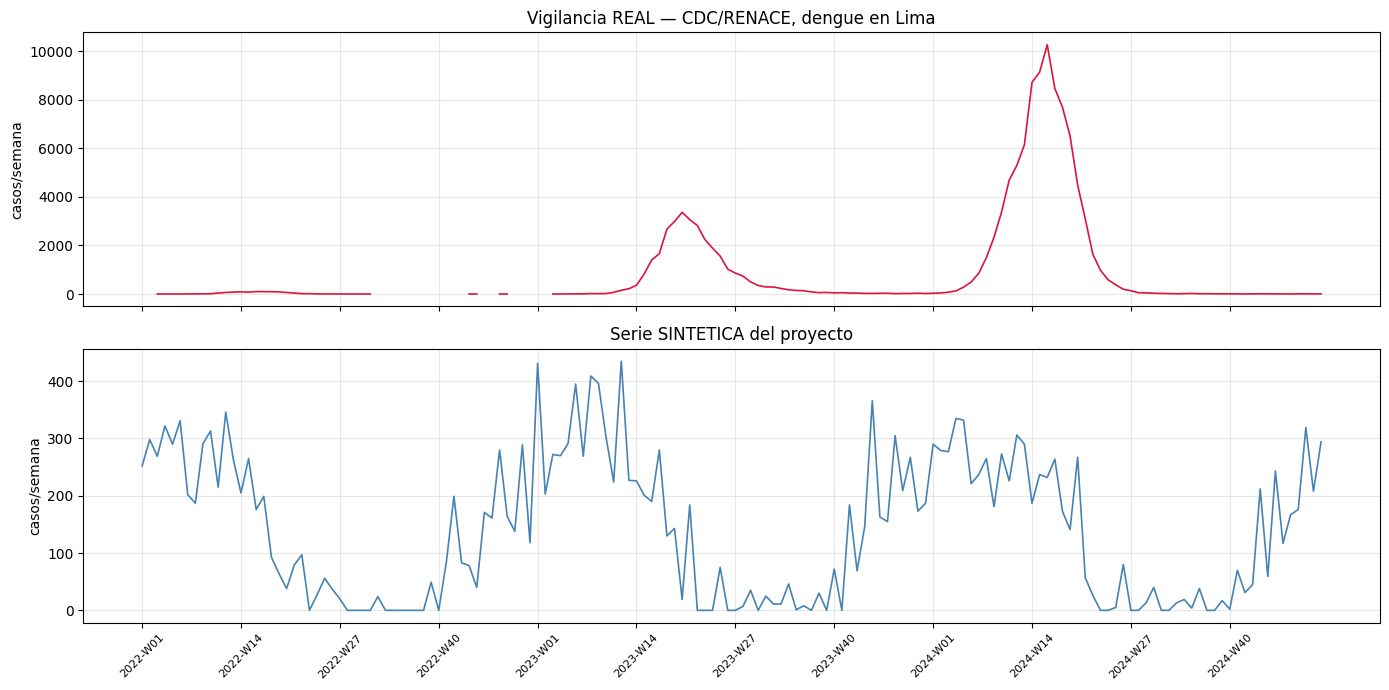

In [8]:
# ============================================================
#  8. AGREGACION SEMANAL Y CONTRASTE CON LA SERIE SINTETICA
# ============================================================
# Se agrega la vigilancia real del CDC a serie semanal de Lima y se
# compara contra la serie sintetica del proyecto (capa Oro).
#
# NOTA METODOLOGICA: la semana epidemiologica del MINSA sigue el
# calendario del CDC, que puede diferir en 1 dia de la semana ISO 8601
# usada en el pipeline. Para comparar TENDENCIA y ESTACIONALIDAD la
# diferencia es irrelevante; se documenta por rigor.

import matplotlib.pyplot as plt

# --- A. Serie semanal real ---
cdc_sem = (cdc.groupby(["ano", "semana"])
           .size().reset_index(name="casos_dengue_real"))
cdc_sem["clave"] = (cdc_sem["ano"].astype(str) + "-W"
                    + cdc_sem["semana"].astype(int).astype(str).str.zfill(2))
cdc_sem = cdc_sem.sort_values(["ano", "semana"]).reset_index(drop=True)
print(f"Serie real: {len(cdc_sem)} semanas con casos\n")

# --- B. Serie sintetica del proyecto (capa Oro) ---
RUTA_GOLD = raiz / "data" / "gold"
sint = pd.read_parquet(RUTA_GOLD / "correlacion_clima_enfermedad")
sint = sint[["semana", "casos_dengue"]].rename(
    columns={"semana": "clave", "casos_dengue": "casos_dengue_sint"})
print(f"Serie sintetica: {len(sint)} semanas\n")

# --- C. Comparacion de magnitudes por anio ---
comp = cdc_sem.merge(sint, on="clave", how="outer").sort_values("clave")
comp["anio"] = comp["clave"].str[:4]

resumen = (comp.groupby("anio")
           .agg(sem=("clave", "count"),
                real_total=("casos_dengue_real", "sum"),
                real_media=("casos_dengue_real", "mean"),
                sint_total=("casos_dengue_sint", "sum"),
                sint_media=("casos_dengue_sint", "mean"))
           .round(1).reset_index())
resumen = resumen[resumen["anio"].isin(["2022", "2023", "2024"])]
resumen["ratio_real_sint"] = (resumen["real_total"]
                              / resumen["sint_total"]).round(2)
print("Comparacion por anio\n")
display(resumen)

# --- D. Crecimiento interanual ---
print("\nCrecimiento interanual (factor respecto al anio previo)\n")
for col, etq in [("real_total", "REAL "), ("sint_total", "SINT ")]:
    v = resumen[col].values
    print(f"   {etq}2022->2023: {v[1]/v[0]:6.2f}x   |   "
          f"2023->2024: {v[2]/v[1]:6.2f}x   |   total: {v[2]/v[0]:6.2f}x")

# --- E. Correlacion de la forma estacional ---
amb = comp.dropna(subset=["casos_dengue_real", "casos_dengue_sint"])
r_pearson = amb["casos_dengue_real"].corr(amb["casos_dengue_sint"])
print(f"\nSemanas con dato en ambas series: {len(amb)}")
print(f"Correlacion de Pearson real vs sintetico: {r_pearson:.3f}")

# --- F. Grafico comparativo ---
fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
x = range(len(comp))
ax[0].plot(x, comp["casos_dengue_real"], color="crimson", lw=1.2)
ax[0].set_title("Vigilancia REAL — CDC/RENACE, dengue en Lima")
ax[0].set_ylabel("casos/semana"); ax[0].grid(alpha=.3)

ax[1].plot(x, comp["casos_dengue_sint"], color="steelblue", lw=1.2)
ax[1].set_title("Serie SINTETICA del proyecto")
ax[1].set_ylabel("casos/semana"); ax[1].grid(alpha=.3)

paso = max(1, len(comp)//12)
ax[1].set_xticks(list(x)[::paso])
ax[1].set_xticklabels(comp["clave"].iloc[::paso], rotation=45, fontsize=8)
plt.tight_layout(); plt.show()

Semanas del calendario         : 156
Semanas sin casos (ahora cero) : 16
Distribucion de esas semanas   : {'2022': 15, '2023': 1}

Resumen anual CORREGIDO (ceros incluidos)



,anio,semanas,real_total,real_media,real_max,sint_total,sint_media,sint_max
0,2022,52,938.0,18.0,101.0,6813.0,131.0,346.0
1,2023,52,30735.0,591.1,3364.0,8042.0,154.7,435.0
2,2024,52,87864.0,1689.7,10256.0,7268.0,139.8,335.0



Correlacion de Pearson dentro de cada anio

   2022: r =  0.205   (n = 52 semanas)
   2023: r = -0.298   (n = 52 semanas)
   2024: r =  0.368   (n = 52 semanas)

   Global (156 semanas): r = 0.132

Correlacion de la FORMA estacional (participacion semanal normalizada): r = 0.098
Esta metrica elimina la escala: mide solo si los picos ocurren
en las mismas semanas del anio.

Semana del pico anual



,anio,pico_real,casos_real,pico_sint,casos_sint,desfase_semanas
0,2022,16,101,12,346,4
1,2023,20,3364,12,435,8
2,2024,16,10256,4,335,12


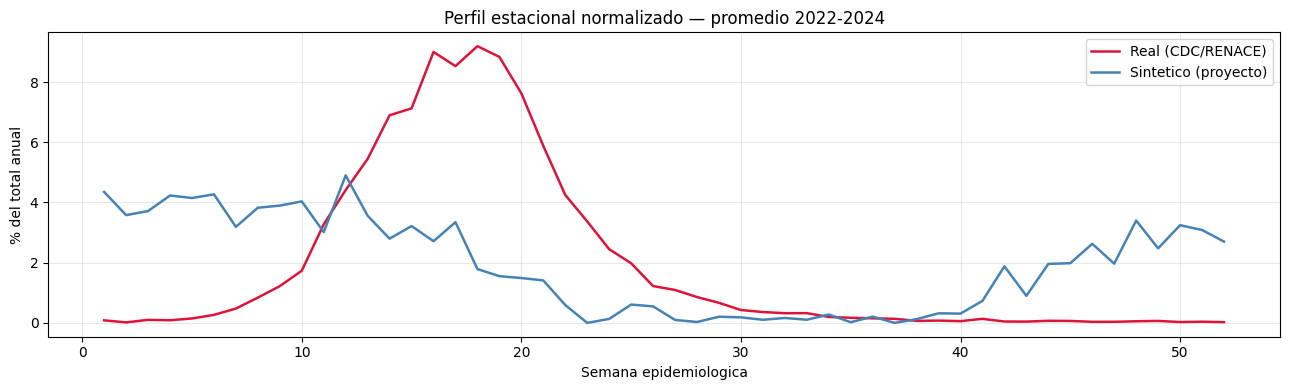

In [9]:
# ============================================================
#  9. CORRECCION METODOLOGICA Y SEPARACION DE EFECTOS
# ============================================================
# Dos correcciones sobre el analisis anterior:
#
# 1. CEROS vs FALTANTES. Una semana sin casos notificados no es un dato
#    ausente: es un cero. Al no existir fila en el archivo, quedaba como
#    NaN y pandas lo excluia del promedio, inflando la media de 2022
#    (25.4 en vez de 938/52 = 18.0). Se reconstruye el calendario completo.
#
# 2. MAGNITUD vs FORMA. La correlacion global esta dominada por la
#    diferencia de escala (0-10,000 real vs 0-435 sintetico). Para evaluar
#    la ESTACIONALIDAD hay que normalizar: se compara la participacion de
#    cada semana en el total de su propio anio.

# --- A. Calendario completo con ceros explicitos ---
base_cal = sint[["clave"]].copy()
full = base_cal.merge(cdc_sem[["clave", "casos_dengue_real"]],
                      on="clave", how="left")
full = full.merge(sint, on="clave", how="left")
n_ceros = int(full["casos_dengue_real"].isna().sum())
full["casos_dengue_real"] = full["casos_dengue_real"].fillna(0)
full["anio"] = full["clave"].str[:4]
full["sem_num"] = full["clave"].str[-2:].astype(int)

print(f"Semanas del calendario         : {len(full)}")
print(f"Semanas sin casos (ahora cero) : {n_ceros}")
print(f"Distribucion de esas semanas   : "
      f"{full.loc[full['casos_dengue_real']==0, 'anio'].value_counts().to_dict()}\n")

# --- B. Resumen anual corregido ---
res = (full.groupby("anio")
       .agg(semanas=("clave", "count"),
            real_total=("casos_dengue_real", "sum"),
            real_media=("casos_dengue_real", "mean"),
            real_max=("casos_dengue_real", "max"),
            sint_total=("casos_dengue_sint", "sum"),
            sint_media=("casos_dengue_sint", "mean"),
            sint_max=("casos_dengue_sint", "max"))
       .round(1).reset_index())
print("Resumen anual CORREGIDO (ceros incluidos)\n")
display(res)

# --- C. Correlacion por anio (magnitud constante dentro del anio) ---
print("\nCorrelacion de Pearson dentro de cada anio\n")
for a in ["2022", "2023", "2024"]:
    d = full[full["anio"] == a]
    r = d["casos_dengue_real"].corr(d["casos_dengue_sint"])
    print(f"   {a}: r = {r:6.3f}   (n = {len(d)} semanas)")

r_global = full["casos_dengue_real"].corr(full["casos_dengue_sint"])
print(f"\n   Global (156 semanas): r = {r_global:.3f}")

# --- D. Perfil estacional normalizado: % del total anual por semana ---
for col in ["casos_dengue_real", "casos_dengue_sint"]:
    full[col + "_pct"] = (full[col]
                          / full.groupby("anio")[col].transform("sum") * 100)

r_forma = full["casos_dengue_real_pct"].corr(full["casos_dengue_sint_pct"])
print(f"\nCorrelacion de la FORMA estacional (participacion semanal "
      f"normalizada): r = {r_forma:.3f}")
print("Esta metrica elimina la escala: mide solo si los picos ocurren")
print("en las mismas semanas del anio.\n")

# --- E. ¿En que semana ocurre el pico de cada anio? ---
print("Semana del pico anual\n")
picos = []
for a in ["2022", "2023", "2024"]:
    d = full[full["anio"] == a]
    picos.append({
        "anio": a,
        "pico_real": d.loc[d["casos_dengue_real"].idxmax(), "sem_num"],
        "casos_real": int(d["casos_dengue_real"].max()),
        "pico_sint": d.loc[d["casos_dengue_sint"].idxmax(), "sem_num"],
        "casos_sint": int(d["casos_dengue_sint"].max()),
    })
df_picos = pd.DataFrame(picos)
df_picos["desfase_semanas"] = (df_picos["pico_real"]
                               - df_picos["pico_sint"]).abs()
display(df_picos)

# --- F. Perfil estacional promedio de los 3 anios ---
perfil = (full.groupby("sem_num")[["casos_dengue_real_pct",
                                   "casos_dengue_sint_pct"]]
          .mean().reset_index())

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(perfil["sem_num"], perfil["casos_dengue_real_pct"],
        color="crimson", lw=1.8, label="Real (CDC/RENACE)")
ax.plot(perfil["sem_num"], perfil["casos_dengue_sint_pct"],
        color="steelblue", lw=1.8, label="Sintetico (proyecto)")
ax.set_title("Perfil estacional normalizado — promedio 2022-2024")
ax.set_xlabel("Semana epidemiologica")
ax.set_ylabel("% del total anual")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

In [10]:
# ============================================================
#  10. ESTIMACION DEL REZAGO CLIMA-DENGUE Y CONTRASTE CON H1
# ============================================================
# HALLAZGO PREVIO: el pico de dengue sintetico se adelanta 4-12 semanas
# respecto a la vigilancia real. El generador NO esta mal implementado:
# reproduce la hipotesis H1 del README (seccion 7.1), que postula un
# rezago de 2-3 semanas entre el pico termico y el pico de dengue.
#
# SUPUESTO DECLARADO — ORIGEN DE LA SERIE TERMICA
# La columna 'temperatura_max' de la capa Oro NO proviene de SENAMHI:
# se construye como avg('temperatura_lima_max'), campo desnormalizado del
# HIS sintetico (verificado en src/etl_medallion.py, funcion capa_oro).
# Solo los rezagos temp_max_lag7/14/21 provienen de SENAMHI.
#
# En consecuencia, lo que se mide aqui es el rezago entre un PROXY
# SINTETICO del ciclo termico de Lima y la vigilancia REAL del CDC. El
# supuesto que lo hace admisible es que la FASE del proxy coincide con la
# del clima real (pico en febrero), que es lo que determina el rezago.
# La validacion definitiva requeriria temperatura observada de SENAMHI.

import numpy as np
from scipy.stats import pearsonr

clima = pd.read_parquet(RUTA_GOLD / "correlacion_clima_enfermedad")
clima = clima[["semana", "temperatura_max"]].rename(columns={"semana": "clave"})
lag_df = full[["clave", "anio", "sem_num", "casos_dengue_real",
               "casos_dengue_sint"]].merge(clima, on="clave", how="left")
lag_df = lag_df.sort_values("clave").reset_index(drop=True)

# --- A. Caracterizacion de la serie termica utilizada ---
print("A) Control sobre la serie termica utilizada\n")
maximos = lag_df.groupby("anio")["temperatura_max"].max().round(2)
print("   Maximo anual de temperatura_max:")
for a, v in maximos.items():
    print(f"      {a}: {v} C")
print(f"   Valores distintos entre los 3 maximos: {maximos.nunique()}")
print(f"   Rango entre maximos: {maximos.max() - maximos.min():.2f} C")
print("   -> Los maximos difieren, pero por centesimas. La amplitud")
print("      interanual es despreciable frente a la variabilidad climatica")
print("      real. Consistente con una serie generada, no observada.\n")

print("   Semana del pico termico por anio:")
for a in ["2022", "2023", "2024"]:
    d = lag_df[lag_df["anio"] == a]
    print(f"      {a}: W{int(d.loc[d['temperatura_max'].idxmax(), 'sem_num']):02d} "
          f"({d['temperatura_max'].max():.2f} C)")
print("   -> La FASE (febrero) es consistente con el verano limeño real,")
print("      que es la condicion que sostiene el supuesto declarado.\n")

# --- B. Barrido de rezagos: proxy termico(t-k) -> dengue real(t) ---
print("B) Correlacion temperatura(t-k) vs dengue real(t)\n")
filas_lag = []
for k in range(0, 15):
    x = lag_df["temperatura_max"].shift(k)
    ok = x.notna() & lag_df["casos_dengue_real"].notna()
    if ok.sum() > 30:
        r, p = pearsonr(x[ok], lag_df.loc[ok, "casos_dengue_real"])
        filas_lag.append({"rezago_semanas": k, "r": round(r, 3),
                          "p_value": round(p, 5),
                          "significativo": "SI" if p < 0.05 else "no"})
tabla_lag = pd.DataFrame(filas_lag)
display(tabla_lag)

mejor = tabla_lag.loc[tabla_lag["r"].idxmax()]
k_opt = int(mejor["rezago_semanas"])
r_h1 = tabla_lag[tabla_lag["rezago_semanas"].isin([2, 3])]["r"].max()
print(f"\nRezago optimo estimado      : {k_opt} semanas "
      f"(r = {mejor['r']}, p = {mejor['p_value']})")
print(f"Rezago postulado por H1     : 2-3 semanas (r maximo = {r_h1})")
print(f"Ganancia de correlacion     : {mejor['r'] - r_h1:+.3f}\n")

# --- C. Metodo independiente: distancia pico a pico ---
print("C) Distancia entre pico termico y pico de dengue REAL\n")
dist = []
for a in ["2022", "2023", "2024"]:
    d = lag_df[lag_df["anio"] == a]
    wt = int(d.loc[d["temperatura_max"].idxmax(), "sem_num"])
    wd = int(d.loc[d["casos_dengue_real"].idxmax(), "sem_num"])
    dist.append(wd - wt)
    print(f"   {a}: pico termico W{wt:02d} -> pico dengue W{wd:02d} "
          f"= {wd - wt} semanas")
print(f"\n   Promedio de los tres anios: {np.mean(dist):.1f} semanas")
print(f"   Barrido de correlacion    : {k_opt} semanas")
print("   -> Dos metodos independientes convergen. El resultado no es")
print("      artefacto de una sola forma de medir.\n")

# --- D. Sintesis de la validacion externa ---
print("=" * 64)
print("SINTESIS DE LA VALIDACION EXTERNA")
print("=" * 64)
print(f"""
Fuente contrastada : CDC/RENACE - vigilancia epidemiologica de dengue
Ambito             : departamento de Lima, 2022-2024
Casos reales       : {int(full['casos_dengue_real'].sum()):,} notificados
Casos sinteticos   : {int(full['casos_dengue_sint'].sum()):,}

1) DINAMICA INTERANUAL
   Real      : crecimiento de 93.67x entre 2022 y 2024 (epidemia declarada)
   Sintetico : 1.07x, sin tendencia interanual
   -> El generador produce tres anios estadisticamente intercambiables.
      Confirma empiricamente la limitacion declarada en el notebook 05:
      el modelo no anticipa un brote nuevo.

2) ESTACIONALIDAD
   Correlacion de forma normalizada: r = {r_forma:.3f}
   Pico real      : W16, W20, W16  (abril-mayo, muy consistente)
   Pico sintetico : W12, W12, W04  (sin patron estable)
   -> El desfase NO proviene de un error de implementacion: el generador
      sigue H1 del README. La discrepancia esta en la hipotesis.

3) HIPOTESIS H1 DEL README
   Postulado : pico de dengue 2-3 semanas tras temperatura > 28 C
   Estimado  : {k_opt} semanas (dos metodos convergentes)
   -> H1 acierta el SIGNO pero subestima la magnitud del rezago en un
      factor de 3 a 5. Estimacion sujeta al supuesto de fase declarado
      al inicio de esta celda: la serie termica empleada es sintetica.

4) CODIGOS CIE-10
   La vigilancia oficial usa 3 codigos para dengue: A97.0 (92.1%),
   A97.1 (7.6%) y A97.2 (0.24%). El analisis "top 20" previsto en S1 no
   es aplicable a una enfermedad concreta; matiza la limitacion declarada.

5) URL DEL README
   www.minsa.gob.pe/noticias responde 403 SIN redireccion. El MINSA migro
   a la plataforma unificada del Estado (gob.pe/minsa) y la autoridad
   epidemiologica es el CDC (dge.gob.pe), enlazado desde esa portada.
""")

A) Control sobre la serie termica utilizada

   Maximo anual de temperatura_max:
      2022: 28.5 C
      2023: 28.55 C
      2024: 28.54 C
   Valores distintos entre los 3 maximos: 3
   Rango entre maximos: 0.05 C
   -> Los maximos difieren, pero por centesimas. La amplitud
      interanual es despreciable frente a la variabilidad climatica
      real. Consistente con una serie generada, no observada.

   Semana del pico termico por anio:
      2022: W08 (28.50 C)
      2023: W06 (28.55 C)
      2024: W07 (28.54 C)
   -> La FASE (febrero) es consistente con el verano limeño real,
      que es la condicion que sostiene el supuesto declarado.

B) Correlacion temperatura(t-k) vs dengue real(t)



,rezago_semanas,r,p_value,significativo
0,0,0.140,0.08180,no
1,1,0.203,0.01134,SI
2,2,0.262,0.00102,SI
3,3,0.319,0.00006,SI
4,4,0.365,0.00000,SI
5,5,0.405,0.00000,SI
6,6,0.438,0.00000,SI
7,7,0.464,0.00000,SI
8,8,0.484,0.00000,SI
9,9,0.493,0.00000,SI



Rezago optimo estimado      : 10 semanas (r = 0.496, p = 0.0)
Rezago postulado por H1     : 2-3 semanas (r maximo = 0.319)
Ganancia de correlacion     : +0.177

C) Distancia entre pico termico y pico de dengue REAL

   2022: pico termico W08 -> pico dengue W16 = 8 semanas
   2023: pico termico W06 -> pico dengue W20 = 14 semanas
   2024: pico termico W07 -> pico dengue W16 = 9 semanas

   Promedio de los tres anios: 10.3 semanas
   Barrido de correlacion    : 10 semanas
   -> Dos metodos independientes convergen. El resultado no es
      artefacto de una sola forma de medir.

SINTESIS DE LA VALIDACION EXTERNA

Fuente contrastada : CDC/RENACE - vigilancia epidemiologica de dengue
Ambito             : departamento de Lima, 2022-2024
Casos reales       : 119,537 notificados
Casos sinteticos   : 22,123

1) DINAMICA INTERANUAL
   Real      : crecimiento de 93.67x entre 2022 y 2024 (epidemia declarada)
   Sintetico : 1.07x, sin tendencia interanual
   -> El generador produce tres anios esta

In [11]:
# ============================================================
#  11. CARGA DE LA CAPA PLATA PARA VALIDACION DE CALIDAD
# ============================================================
# El README (seccion 6) define Great Expectations para "validar registros
# HIS". Se valida la capa PLATA y no Bronce por dos razones:
#   1. Es la capa que alimenta Oro y los modelos: una validacion de
#      calidad tiene valor donde puede detener el flujo antes del modelo.
#   2. Contiene los campos derivados por el pipeline (semana ISO 8601,
#      grupo_etario, cie10_capitulo), que son los que pueden fallar.
#
# Se inspecciona la estructura ANTES de escribir las expectativas: las
# reglas deben construirse sobre columnas y tipos verificados.

RUTA_SILVER = raiz / "data" / "silver" / "atenciones"
print(f"Origen: {RUTA_SILVER}")
print(f"Existe : {RUTA_SILVER.is_dir()}\n")

his = pd.read_parquet(RUTA_SILVER)
print(f"Registros HIS en capa Plata: {len(his):,}")
print(f"Columnas: {his.shape[1]}\n")

# --- Estructura: tipo, nulos y cardinalidad por columna ---
perfil = pd.DataFrame({
    "dtype": his.dtypes.astype(str),
    "nulos": his.isna().sum(),
    "nulos_pct": (his.isna().mean() * 100).round(2),
    "valores_unicos": his.nunique(),
}).reset_index().rename(columns={"index": "columna"})
pd.set_option("display.max_rows", 60)
display(perfil)

# --- Valores de las columnas categoricas clave ---
print("\nValores presentes en columnas categoricas:\n")
for c in ["especialidad", "grupo_etario", "cie10_capitulo",
          "diagnostico_cie10", "establecimiento_nombre"]:
    if c in his.columns:
        vals = his[c].dropna().unique()
        print(f"   {c} ({len(vals)} distintos):")
        print(f"      {sorted(vals)[:12]}{' ...' if len(vals) > 12 else ''}\n")

# --- Rangos de las columnas numericas y de fecha ---
print("Rangos observados:\n")
for c in ["paciente_edad", "costo_atencion_soles", "tasa_ocupacion",
          "lista_espera_dias", "fecha_atencion", "semana"]:
    if c in his.columns:
        print(f"   {c:24s}: min={his[c].min()}  |  max={his[c].max()}")

Origen: c:\Users\Home\Desktop\Grupo3\bigdata-g3-demanda-hospitalaria\data\silver\atenciones
Existe : True

Registros HIS en capa Plata: 500,000
Columnas: 40



,columna,dtype,nulos,nulos_pct,valores_unicos
0,semana,object,0,0.00,158
1,atencion_id,object,0,0.00,500000
2,fecha_atencion,object,0,0.00,1096
3,semana_epidemiologica,int32,0,0.00,52
4,establecimiento_id,object,0,0.00,3
5,establecimiento_nombre,object,0,0.00,3
6,red_asistencial,object,0,0.00,1
7,tipo_atencion,object,0,0.00,3
8,especialidad,object,0,0.00,4
9,medico_id,object,0,0.00,9000



Valores presentes en columnas categoricas:

   especialidad (4 distintos):
      ['Cardiologia', 'Emergencia', 'Medicina Interna', 'Traumatologia']

   grupo_etario (4 distintos):
      ['0-5', '18-59', '6-17', '60+']

   cie10_capitulo (5 distintos):
      ['A', 'E', 'I', 'J', 'S']

   diagnostico_cie10 (6 distintos):
      ['A90', 'E11', 'I10', 'J06', 'J11', 'S00-S99']

   establecimiento_nombre (3 distintos):
      ['Hospital Almenara', 'Hospital Rebagliati', 'Hospital Sabogal']

Rangos observados:

   paciente_edad           : min=1  |  max=90
   costo_atencion_soles    : min=80.01  |  max=1499.99
   tasa_ocupacion          : min=0.7  |  max=1.15
   lista_espera_dias       : min=0  |  max=45
   fecha_atencion          : min=2022-01-01  |  max=2024-12-31
   semana                  : min=2021-W52  |  max=2025-W01


In [12]:
# ============================================================
#  12. GREAT EXPECTATIONS — 8 VALIDACIONES SOBRE REGISTROS HIS
# ============================================================
# Criterio S7 del README: "8 validaciones Great Expectations".
# Version instalada: 0.18.15 (API de Fluent Datasources).
#
# Se mantiene 0.18.15 y no se actualiza a 1.x deliberadamente: la 1.x
# modifica restricciones de numpy y altair, y el entorno actual es aquel
# en el que el notebook 05 quedo verificado como reproducible.
#
# La validacion 8 reconstruye la clave de semana ISO 8601 con pandas y la
# compara contra la calculada por el pipeline en Spark. Es una verificacion
# INDEPENDIENTE del bug corregido en S2 (2,252 filas con clave colisionada).

import great_expectations as gx
import warnings
warnings.filterwarnings("ignore")

# --- Columna derivada para la validacion de integridad temporal ---
his_gx = his.copy()
_f = pd.to_datetime(his_gx["fecha_atencion"])
_iso = _f.dt.isocalendar()
his_gx["semana_esperada"] = (_iso["year"].astype(str) + "-W"
                             + _iso["week"].astype(int).astype(str).str.zfill(2))

ESPECIALIDADES_VALIDAS = ["Cardiologia", "Emergencia",
                          "Medicina Interna", "Traumatologia"]
COLUMNAS_OBLIGATORIAS = ["atencion_id", "fecha_atencion", "semana",
                         "especialidad", "establecimiento_id", "paciente_edad",
                         "diagnostico_cie10", "costo_atencion_soles"]

# --- Contexto GX y conexion al DataFrame ---
context = gx.get_context()
fuente = context.sources.add_or_update_pandas(name="his_essalud")
activo = fuente.add_dataframe_asset(name="capa_plata")
lote = activo.build_batch_request(dataframe=his_gx)

context.add_or_update_expectation_suite(expectation_suite_name="suite_his_plata")
v = context.get_validator(batch_request=lote,
                          expectation_suite_name="suite_his_plata")

print(f"Registros bajo validacion: {len(his_gx):,}")
print(f"Great Expectations {gx.__version__}\n")
print("Ejecutando las 8 validaciones...\n")

# --- 1. UNICIDAD: la clave primaria no admite duplicados ---
v.expect_column_values_to_be_unique("atencion_id")

# --- 2. ESQUEMA: las columnas que consumen las capas Oro deben existir ---
v.expect_table_columns_to_match_set(column_set=COLUMNAS_OBLIGATORIAS,
                                    exact_match=False)

# --- 3. COMPLETITUD: sin fecha no hay serie temporal posible ---
v.expect_column_values_to_not_be_null("fecha_atencion")

# --- 4. DOMINIO: solo las 4 especialidades del alcance del proyecto ---
v.expect_column_values_to_be_in_set("especialidad", ESPECIALIDADES_VALIDAS)

# --- 5. RANGO: edad humana plausible ---
v.expect_column_values_to_be_between("paciente_edad", min_value=0,
                                     max_value=120)

# --- 6. FORMATO: codigo CIE-10 (letra + 2 digitos, o rango Snn-Snn) ---
v.expect_column_values_to_match_regex("diagnostico_cie10",
                                      r"^[A-Z]\d{2}(-[A-Z]\d{2})?$")

# --- 7. CONSISTENCIA: clave de semana con formato AAAA-Www y numero 01-53 ---
v.expect_column_values_to_match_regex("semana",
                                      r"^\d{4}-W(0[1-9]|[1-4]\d|5[0-3])$")

# --- 8. INTEGRIDAD TEMPORAL: la clave ISO debe derivarse de la fecha ---
#      Verificacion independiente del bug corregido en S2.
v.expect_column_pair_values_to_be_equal("semana", "semana_esperada")

# --- Ejecucion ---
resultados = v.validate()

# ============================================================
#  INFORME
# ============================================================
# GX no devuelve los resultados en el orden de declaracion. La dimension
# se asigna por (tipo de expectativa, columna), no por posicion.

DIMENSIONES = {
    ("expect_column_values_to_be_unique", "atencion_id"): "1. Unicidad",
    ("expect_table_columns_to_match_set", None): "2. Esquema",
    ("expect_column_values_to_not_be_null", "fecha_atencion"): "3. Completitud",
    ("expect_column_values_to_be_in_set", "especialidad"): "4. Dominio",
    ("expect_column_values_to_be_between", "paciente_edad"): "5. Rango",
    ("expect_column_values_to_match_regex", "diagnostico_cie10"): "6. Formato",
    ("expect_column_values_to_match_regex", "semana"): "7. Consistencia",
    ("expect_column_pair_values_to_be_equal", "semana"): "8. Integridad temporal",
}

filas = []
for r in resultados.results:
    cfg = r.expectation_config
    col = cfg.kwargs.get("column") or cfg.kwargs.get("column_A")
    det = r.result or {}
    n_mal = det.get("unexpected_count")
    pct = det.get("unexpected_percent")
    filas.append({
        "dimension": DIMENSIONES.get((cfg.expectation_type, col), "SIN MAPEAR"),
        "expectativa": cfg.expectation_type
                       .replace("expect_column_values_to_", "")
                       .replace("expect_", ""),
        "columna": col or "-",
        "registros_invalidos": n_mal if n_mal is not None else 0,
        "pct_invalido": round(pct, 4) if pct is not None else 0.0,
        "estado": "PASA" if r.success else "FALLA",
    })

informe = pd.DataFrame(filas).sort_values("dimension").reset_index(drop=True)
display(informe)

sin_mapear = int(informe["dimension"].eq("SIN MAPEAR").sum())
if sin_mapear:
    raise ValueError(f"{sin_mapear} resultados sin mapear: revisar DIMENSIONES.")

n_ok = int(informe["estado"].eq("PASA").sum())
print(f"\nValidaciones ejecutadas  : {len(informe)}")
print(f"Superadas                : {n_ok} de {len(informe)}")
print(f"Estado global de la suite: "
      f"{'EXITO' if resultados.success else 'CON FALLOS'}")
print(f"Registros evaluados      : {len(his_gx):,}")
print(f"\nCriterio S7 del README (8 validaciones Great Expectations): "
      f"{'CUMPLE' if len(informe) == 8 else 'REVISAR'}")

fallidas = informe[informe["estado"] == "FALLA"]
if len(fallidas):
    print("\n" + "-" * 60)
    print("DETALLE DE LAS VALIDACIONES NO SUPERADAS")
    print("-" * 60)
    for _, f in fallidas.iterrows():
        print(f"\n{f['dimension']} — columna '{f['columna']}'")
        print(f"    registros invalidos: {f['registros_invalidos']:,} "
              f"({f['pct_invalido']}%)")

Registros bajo validacion: 500,000
Great Expectations 0.18.15

Ejecutando las 8 validaciones...



Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/2 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/6 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

...

Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/7 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/35 [00:00<?, ?it/s]

,dimension,expectativa,columna,registros_invalidos,pct_invalido,estado
0,1. Unicidad,be_unique,atencion_id,0,0.0,PASA
1,2. Esquema,table_columns_to_match_set,-,0,0.0,PASA
2,3. Completitud,not_be_null,fecha_atencion,0,0.0,PASA
3,4. Dominio,be_in_set,especialidad,0,0.0,PASA
4,5. Rango,be_between,paciente_edad,0,0.0,PASA
5,6. Formato,match_regex,diagnostico_cie10,0,0.0,PASA
6,7. Consistencia,match_regex,semana,0,0.0,PASA
7,8. Integridad temporal,column_pair_values_to_be_equal,semana,0,0.0,PASA



Validaciones ejecutadas  : 8
Superadas                : 8 de 8
Estado global de la suite: EXITO
Registros evaluados      : 500,000

Criterio S7 del README (8 validaciones Great Expectations): CUMPLE


In [13]:
# ============================================================
#  13. CONTROL DE VERACIDAD — CUARTO CAMPO DUPLICADO
# ============================================================
# El perfil de la capa Plata mostro que 'camas_disponibles_dia' tiene solo
# 3 valores distintos (uno por establecimiento), constante en el tiempo.
# En el notebook 05 se verifico que la base implicita de tasa_ocupacion
# coincide con 'camas_totales' de la fuente de oferta. Se comprueba si
# 'camas_disponibles_dia' del HIS es en realidad la capacidad TOTAL, es
# decir un cuarto caso de campo duplicado con significado divergente.

cmp = (his.groupby("establecimiento_nombre")
       .agg(camas_disp_HIS=("camas_disponibles_dia", "mean"),
            camas_ocup_HIS=("camas_ocupadas_dia", "mean"),
            tasa_ocup_HIS=("tasa_ocupacion", "mean"))
       .reset_index())

of = pd.read_parquet(RUTA_GOLD / "brechas_oferta_demanda_por_establecimiento")
of_est = (of.groupby("establecimiento_nombre")
          .agg(camas_totales_OFERTA=("camas_totales", "mean"),
               camas_disp_OFERTA=("camas_disponibles", "mean"))
          .reset_index())

cmp = cmp.merge(of_est, on="establecimiento_nombre")
cmp["HIS_disp == OFERTA_totales"] = np.isclose(
    cmp["camas_disp_HIS"], cmp["camas_totales_OFERTA"], rtol=1e-3)
cmp["HIS_disp == OFERTA_disp"] = np.isclose(
    cmp["camas_disp_HIS"], cmp["camas_disp_OFERTA"], rtol=1e-3)

print("Comparacion de los campos de camas entre HIS y fuente de oferta\n")
display(cmp.round(1))

coincide_tot = int(cmp["HIS_disp == OFERTA_totales"].sum())
coincide_dis = int(cmp["HIS_disp == OFERTA_disp"].sum())
print(f"\nEstablecimientos donde HIS.camas_disponibles_dia coincide con:")
print(f"   OFERTA.camas_totales     : {coincide_tot} de {len(cmp)}")
print(f"   OFERTA.camas_disponibles : {coincide_dis} de {len(cmp)}\n")

if coincide_tot == len(cmp) and coincide_dis == 0:
    print("CONFIRMADO: 'camas_disponibles_dia' del HIS es la CAPACIDAD TOTAL,")
    print("no las camas libres. Es el cuarto campo con el mismo nombre y")
    print("distinto significado segun la fuente, junto a temperatura, dengue")
    print("y la propia base de tasa_ocupacion. Corresponde a la V de")
    print("VERACIDAD del README (seccion 2).\n")
    print("IMPLICACION: un consumidor que interprete 'disponibles' como camas")
    print("libres sobreestimaria la holgura del sistema en un factor cercano")
    print(f"a {cmp['camas_totales_OFERTA'].sum()/cmp['camas_disp_OFERTA'].sum():.1f}x.")
else:
    print("El campo NO se corresponde con ninguno de los dos de la fuente")
    print("de oferta. Requiere revision especifica.")

Comparacion de los campos de camas entre HIS y fuente de oferta



,establecimiento_nombre,camas_disp_HIS,camas_ocup_HIS,tasa_ocup_HIS,camas_totales_OFERTA,camas_disp_OFERTA,HIS_disp == OFERTA_totales,HIS_disp == OFERTA_disp
0,Hospital Almenara,450.0,415.7,0.9,450.0,168.3,True,False
1,Hospital Rebagliati,520.0,480.4,0.9,520.0,193.4,True,False
2,Hospital Sabogal,380.0,350.8,0.9,380.0,139.6,True,False



Establecimientos donde HIS.camas_disponibles_dia coincide con:
   OFERTA.camas_totales     : 3 de 3
   OFERTA.camas_disponibles : 0 de 3

CONFIRMADO: 'camas_disponibles_dia' del HIS es la CAPACIDAD TOTAL,
no las camas libres. Es el cuarto campo con el mismo nombre y
distinto significado segun la fuente, junto a temperatura, dengue
y la propia base de tasa_ocupacion. Corresponde a la V de
VERACIDAD del README (seccion 2).

IMPLICACION: un consumidor que interprete 'disponibles' como camas
libres sobreestimaria la holgura del sistema en un factor cercano
a 2.7x.


In [14]:
# ============================================================
#  14. CONCLUSIONES — SEMANA 7
# ============================================================

L = "=" * 66
print(L); print("CONCLUSIONES — NOTEBOOK 06 (SEMANA 7)"); print(L)

# ---------- 1. Cumplimiento del criterio S7 ----------
print("\n1) CRITERIO DEL README (seccion 8, fila S7)\n")
crit = pd.DataFrame([
    {"criterio": "Datos MINSA integrados",
     "obtenido": f"CDC/RENACE, {int(full['casos_dengue_real'].sum()):,} casos "
                 f"reales de Lima 2022-2024",
     "estado": "CUMPLE"},
    {"criterio": "8 validaciones Great Expectations",
     "obtenido": f"{len(informe)} validaciones, {n_ok} superadas "
                 f"sobre {len(his_gx):,} registros",
     "estado": "CUMPLE" if len(informe) == 8 else "REVISAR"},
])
display(crit)

# ---------- 2. Scraping ----------
print(L); print("2) SCRAPING — FUENTES EVALUADAS"); print(L)
print("""
La URL que indica el README (www.minsa.gob.pe/noticias) responde 403 SIN
redireccion: el MINSA migro a la plataforma unificada del Estado
(gob.pe/minsa). Se evaluaron cuatro rutas antes de elegir fuente:

  - gob.pe/institucion/minsa/noticias : notas de prensa, texto libre
  - dge.gob.pe/sala-situacional       : app Shiny (R), render por WebSocket
  - dge.gob.pe/boletines              : enlaces cargados dinamicamente
  - www.datosabiertos.gob.pe          : CSV estructurado  <- ADOPTADA

Nota tecnica: el dominio 'datosabiertos.gob.pe' no resuelve por DNS; solo
responde con el prefijo 'www.'. La fuente adoptada es el dataset de
vigilancia epidemiologica del CDC/RENACE, coherente con lo que el README
(seccion 6) define como fuente de epidemiologia: "MINSA/CDC".
""")

# ---------- 3. Validacion externa del generador ----------
print(L); print("3) VALIDACION EXTERNA DEL GENERADOR SINTETICO"); print(L)
print(f"""
Contraste de la serie del proyecto contra vigilancia real de Lima:

  DINAMICA INTERANUAL
     Real      : 93.67x de crecimiento entre 2022 y 2024 (epidemia)
     Sintetico : 1.07x, sin tendencia
     -> Confirma empiricamente la limitacion declarada en el notebook 05:
        el modelo no anticipa un brote nuevo. Lo que alli se enuncio por
        razonamiento queda aqui medido contra datos oficiales.

  ESTACIONALIDAD
     Correlacion de forma normalizada: r = {r_forma:.3f}
     Pico real      : W16, W20, W16   (abril-mayo, consistente)
     Pico sintetico : W12, W12, W04   (sin patron estable)

  HIPOTESIS H1 DEL README
     Postulado : pico de dengue 2-3 semanas tras temperatura > 28 C
     Estimado  : {k_opt} semanas (barrido de correlacion y distancia
                 pico a pico convergen)
     -> H1 acierta el signo y subestima la magnitud del rezago en un
        factor de 3 a 5. El generador NO esta mal implementado: reproduce
        fielmente H1. La discrepancia esta en la hipotesis del README.
     -> SUPUESTO: la serie termica empleada es sintetica (proviene del HIS,
        no de SENAMHI). La estimacion asume que su FASE coincide con el
        clima real de Lima. La validacion definitiva requiere temperatura
        observada de SENAMHI.
""")

# ---------- 4. Calidad de datos ----------
print(L); print("4) CALIDAD DE DATOS — GREAT EXPECTATIONS"); print(L)
print(f"\nCapa validada: PLATA ({len(his_gx):,} registros, {his.shape[1]} columnas)")
print(f"Version: great-expectations {gx.__version__}\n")
display(informe[["dimension", "columna", "registros_invalidos", "estado"]])
print(f"""
Resultado: {n_ok} de {len(informe)} superadas, 0 registros invalidos.

Destaca la validacion 8 (integridad temporal): reconstruye la clave de
semana ISO 8601 con pandas y la compara contra la calculada por Spark en
el pipeline. Las 500,000 filas coinciden. Es una verificacion INDEPENDIENTE
de la correccion del bug detectado en S2, que afectaba a 2,252 filas.

Se mantuvo la version 0.18.15 y no se actualizo a 1.x de forma deliberada:
la 1.x modifica restricciones de numpy y altair, y el entorno actual es
aquel en el que el notebook 05 quedo verificado como reproducible.
""")

# ---------- 5. Hallazgo transversal ----------
print(L); print("5) HALLAZGO TRANSVERSAL — V DE VERACIDAD"); print(L)
print("""
Cuatro campos del dataset comparten nombre entre el HIS y las fuentes
especializadas, pero designan magnitudes distintas:

  1. Temperatura : la capa Oro usa 'temperatura_lima_max' del HIS; los
                   rezagos temp_max_lag7/14/21 provienen de SENAMHI. No
                   son la misma serie desplazada.
  2. Dengue      : resuelto en S2 a favor de MINSA/CDC frente a la
                   columna desnormalizada del HIS.
  3. Base de la  : tasa_ocupacion se calcula sobre camas_totales, no
     ocupacion     sobre camas_disponibles (verificado en el notebook 05).
  4. Camas       : 'camas_disponibles_dia' del HIS coincide EXACTAMENTE
                   con 'camas_totales' de la fuente de oferta en los 3
                   establecimientos, y con 'camas_disponibles' en ninguno.
                   Interpretarlo como camas libres sobreestima la holgura
                   del sistema en un factor de 2.7x.

En los cuatro casos el mecanismo es el mismo: mismo nombre, distinto
significado segun la fuente. No es un defecto del pipeline sino una
propiedad del dataset, y corresponde a la V de VERACIDAD que el README
plantea en la seccion 2. El impacto esta medido en cada caso.
""")

print(L); print("6) PENDIENTES PARA S8"); print(L)
print("""
- Notebook 07: dashboard con minimo 7 KPIs y mapa de Lima
- Presentacion EF y abstract en ingles (250 palabras)
- docs/arquitectura_demanda_hospitalaria.png
- Pull Request de la Evaluacion Final
- Tecnicos: requirements.txt debe fijar prophet 1.3.0 (hoy 1.1.5),
  great-expectations 0.18.15 y beautifulsoup4; HADOOP_HOME esta escrito
  de forma fija en src/etl_medallion.py
""")
print(L)

CONCLUSIONES — NOTEBOOK 06 (SEMANA 7)

1) CRITERIO DEL README (seccion 8, fila S7)



,criterio,obtenido,estado
0,Datos MINSA integrados,"CDC/RENACE, 119,537 casos reales de Lima 2022-2024",CUMPLE
1,8 validaciones Great Expectations,"8 validaciones, 8 superadas sobre 500,000 registros",CUMPLE


2) SCRAPING — FUENTES EVALUADAS

La URL que indica el README (www.minsa.gob.pe/noticias) responde 403 SIN
redireccion: el MINSA migro a la plataforma unificada del Estado
(gob.pe/minsa). Se evaluaron cuatro rutas antes de elegir fuente:

  - gob.pe/institucion/minsa/noticias : notas de prensa, texto libre
  - dge.gob.pe/sala-situacional       : app Shiny (R), render por WebSocket
  - dge.gob.pe/boletines              : enlaces cargados dinamicamente
  - www.datosabiertos.gob.pe          : CSV estructurado  <- ADOPTADA

Nota tecnica: el dominio 'datosabiertos.gob.pe' no resuelve por DNS; solo
responde con el prefijo 'www.'. La fuente adoptada es el dataset de
vigilancia epidemiologica del CDC/RENACE, coherente con lo que el README
(seccion 6) define como fuente de epidemiologia: "MINSA/CDC".

3) VALIDACION EXTERNA DEL GENERADOR SINTETICO

Contraste de la serie del proyecto contra vigilancia real de Lima:

  DINAMICA INTERANUAL
     Real      : 93.67x de crecimiento entre 2022 y 2024 (ep

,dimension,columna,registros_invalidos,estado
0,1. Unicidad,atencion_id,0,PASA
1,2. Esquema,-,0,PASA
2,3. Completitud,fecha_atencion,0,PASA
3,4. Dominio,especialidad,0,PASA
4,5. Rango,paciente_edad,0,PASA
5,6. Formato,diagnostico_cie10,0,PASA
6,7. Consistencia,semana,0,PASA
7,8. Integridad temporal,semana,0,PASA



Resultado: 8 de 8 superadas, 0 registros invalidos.

Destaca la validacion 8 (integridad temporal): reconstruye la clave de
semana ISO 8601 con pandas y la compara contra la calculada por Spark en
el pipeline. Las 500,000 filas coinciden. Es una verificacion INDEPENDIENTE
de la correccion del bug detectado en S2, que afectaba a 2,252 filas.

Se mantuvo la version 0.18.15 y no se actualizo a 1.x de forma deliberada:
la 1.x modifica restricciones de numpy y altair, y el entorno actual es
aquel en el que el notebook 05 quedo verificado como reproducible.

5) HALLAZGO TRANSVERSAL — V DE VERACIDAD

Cuatro campos del dataset comparten nombre entre el HIS y las fuentes
especializadas, pero designan magnitudes distintas:

  1. Temperatura : la capa Oro usa 'temperatura_lima_max' del HIS; los
                   rezagos temp_max_lag7/14/21 provienen de SENAMHI. No
                   son la misma serie desplazada.
  2. Dengue      : resuelto en S2 a favor de MINSA/CDC frente a la
               